#Simulación de poblaciones con Cadenas de Markov

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Definimos una funcion para simular una cadena de Markov para un individuo de la población

In [2]:
#Definimos una funcion para simular n pasos de una CM
def simular_CM(matriz_transicion,estados,estado_inicial,n_pasos):

  #Iniciamos la cadena con el estado inicial
  cadena = [estado_inicial]
  estado_actual = estado_inicial

  for _ in range(n_pasos):
    indice_estado_actual = estados.index(estado_actual)
    prob_transicion = matriz_transicion[indice_estado_actual]

    sig_estado = np.random.choice(estados,p=prob_transicion)
    cadena.append(sig_estado)
    estado_actual = sig_estado

  cadena = pd.Series(cadena)

  return cadena

Probemos la función

In [ ]:
#Definimos el conjunto de estados
S = ["1","2","3"]

#Definimos la matriz de transicion
P = np.array([
    [0.1,0.3,0.6],
    [0.2,0.2,0.6],
    [0.5,0.4,0.1]
])

#Simulamos la cadena con n pasos y guardamos el historial
n_pasos = 20
historial = simular_CM(P,S,"1",n_pasos)
historial

,0
0,1
1,2
2,2
3,3
4,2
5,3
6,2
7,1
8,3
9,1


Usemos la función para definir otra en la que simularemos a N individuos, con la dinámica de cada uno siguiendo una Cadena de Markov

In [3]:
def simular_poblacion_CM(N,P,S,dist_inicial,n_pasos):

  #Inicializamos un diccionario para convertirlo en un dataFrame de pandas
  #en el cual las columnas serán los individuos y las filas los pasos de tiempo
  hist = {}

  #Iteramos para cada individuo de la poblacion
  for i in range(1,N+1):
    #El estado inicial de cada individuo se asigna con la distribucion inicial
    estado_inicial = np.random.choice(S,p=dist_inicial)
    #Simulamos a cada individuo como una CM
    ind_i = simular_CM(P,S,estado_inicial,n_pasos)
    #Las columnas del df serán los individuos y las filas los pasos
    columna = f"Individuo_{i}"
    hist[columna] = ind_i

  hist = pd.DataFrame(hist)
  matriz_vals = hist.values

  #Calculamos las proporciones para cada paso y las almacenamos en un dataFrame
  prop = pd.DataFrame({
    estado: np.sum(matriz_vals == estado, axis=1) / N
    for estado in S
  }, columns=S)

  return hist,prop


Probemos la función para simular a una población de N individuos

In [ ]:
N = 1000000
n_pasos = 20

S = ["1","2","3"]

P = np.array([
    [0.75,0.25,0],
    [0.2,0,0.8],
    [0,0,1]
])

#Vector inicial de proporciones
dist_inicial = [0.9,0.1,0]

hist1,proporciones1 = simular_poblacion_CM(N,P,S,dist_inicial,n_pasos)
proporciones1

KeyboardInterrupt: 

Notamos que para N muy grandes, el tiempo de ejecución es muy alto. Como el estado de cada individuo sigue una distribución categórica, el resultado de simular la población es una suma de variables aleatorias categóricas, que sigue una distribución multinomial. Definiremos una nueva función utilizando este resultado, con el objetivo de reducir el tiempo de ejecución de la simulación.

In [4]:
def simular_poblacion_CM_multinom(N, P, S, dist_inicial, n_pasos):

    num_estados = len(S)
    P = np.asarray(P)

    # Asignamos la población inicial a cada estado según dist_inicial
    # Conteos representa cuántos individuos hay en cada estado del conjunto S
    conteos = np.random.multinomial(N, dist_inicial)

    # Matriz para guardar el número de individuos por estado en cada paso
    # Filas: pasos de tiempo, columnas: estados
    matriz_conteos = np.zeros((n_pasos + 1, num_estados), dtype=int)
    matriz_conteos[0] = conteos

    # Simulamos la evolución usando la Multinomial
    for t in range(1, n_pasos + 1):
        nuevos_conteos = np.zeros(num_estados, dtype=int)

        # Para cada estado i, sus habitantes transicionan en bloque según la fila P[i, :]
        for i in range(num_estados):
            n_i = conteos[i]
            if n_i > 0:
                nuevos_conteos += np.random.multinomial(n_i, P[i, :])

        conteos = nuevos_conteos
        matriz_conteos[t] = conteos

    # Conteo de individuos en cada estado por paso de tiempo
    hist = pd.DataFrame(matriz_conteos, columns=S)

    # Proporciones poblacionales
    prop = hist / N

    return hist, prop

Probamos

In [5]:
N = 1000000
n_pasos = 20

S = [1,2,3]

P = np.array([
    [0.75,0.25,0],
    [0.2,0,0.8],
    [0,0,1]
])

#Vector inicial de proporciones
dist_inicial = [0.9,0.1,0]

hist,proporciones = simular_poblacion_CM_multinom(N,P,S,dist_inicial,n_pasos)

Vemos que el tiempo de ejecución bajó mucho.

Comparemos este enfoque con el de Campo Medio

In [6]:
matriz_teorica = np.array(P)

# El vector de proporciones teóricas inicial es la distribucion inicial
vector_actual = np.array(dist_inicial)
historial_teorico = [vector_actual]

# Multiplicamos iterativamente: X_(t+1) = X_t * P
for _ in range(n_pasos):
    vector_actual = np.dot(vector_actual, matriz_teorica)
    historial_teorico.append(vector_actual)

df_teorico = pd.DataFrame(historial_teorico, columns=S)

In [7]:
poblaciones = [100, 1000, 10000, 1000000]
n_pasos = 20

S = [1,2,3]

P = np.array([
    [0.75,0.25,0],
    [0.2,0,0.8],
    [0,0,1]
])

#Vector inicial de proporciones
dist_inicial = [0.9,0.1,0]

resultados_N = {}

for N in poblaciones:
  _,prop = simular_poblacion_CM_multinom(N,P,S,dist_inicial,n_pasos)
  resultados_N[N] = prop

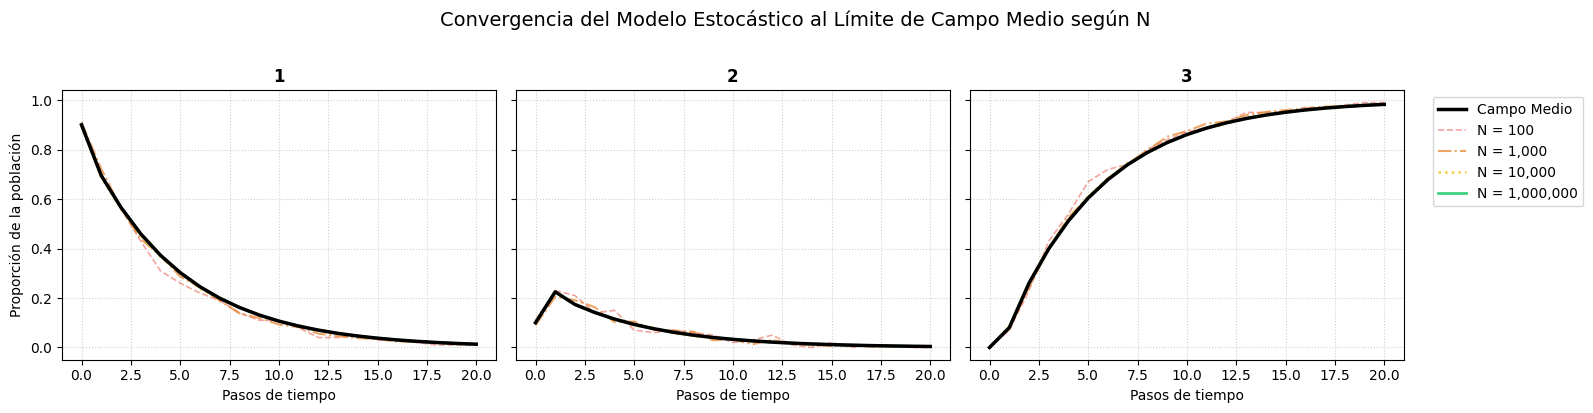

In [10]:
fig, axes = plt.subplots(1,len(S), figsize=(16, 4), sharey=True)

estilos_N = {
    100:     {'color': '#e74c3c', 'alpha': 0.5, 'lw': 1.2, 'ls': '--'},
    1000:    {'color': '#e67e22', 'alpha': 0.7, 'lw': 1.5, 'ls': '-.'},
    10000:   {'color': '#f1c40f', 'alpha': 0.8, 'lw': 1.8, 'ls': ':'},
    1000000: {'color': '#2ecc71', 'alpha': 0.9, 'lw': 2.0, 'ls': '-'}
}

pasos = np.arange(n_pasos + 1)

for idx, estado in enumerate(S):
    ax = axes[idx]

    # A) Usamos tu df_teorico para la línea de Campo Medio (Negra, sólida, gruesa)
    ax.plot(pasos, df_teorico[estado], 'k-', lw=2.5, label='Campo Medio', zorder=5)

    # B) Graficamos las simulaciones de resultados_N
    for N in poblaciones:
        estilo = estilos_N[N]
        ax.plot(
            pasos,
            resultados_N[N][estado],
            label=f'N = {N:,}',
            color=estilo['color'],
            alpha=estilo['alpha'],
            linewidth=estilo['lw'],
            linestyle=estilo['ls']
        )

    ax.set_title(f'{estado}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Pasos de tiempo')
    ax.grid(True, linestyle=':', alpha=0.6)

axes[0].set_ylabel('Proporción de la población')
# Leyenda fuera de las gráficas para que no estorbe
axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

plt.suptitle("Convergencia del Modelo Estocástico al Límite de Campo Medio según N", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Grafiquemos los vectores de proporciones contra los pasos del tiempo de ambas simulaciones para compararlas

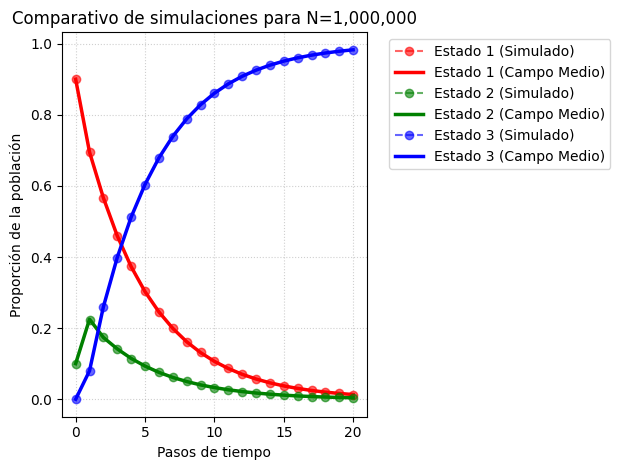

In [11]:
colores = ['red', 'green', 'blue']

for i, estado in enumerate(S):
    # Enfoque estocástico
    plt.plot(proporciones.index, proporciones[estado],
             linestyle='--', marker='o', markersize=6, alpha=0.6, c=colores[i],
             label=f'Estado {estado} (Simulado)')

    # Enfoque determinista
    plt.plot(df_teorico.index, df_teorico[estado],
             linestyle='-', linewidth=2.5, color=colores[i],
             label=f'Estado {estado} (Campo Medio)')

plt.title('Comparativo de simulaciones para N=1,000,000', fontsize=12)
plt.xlabel('Pasos de tiempo', fontsize=10)
plt.ylabel('Proporción de la población', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

plt.show()

Veamos un ejemplo con una CM con un estado absorbente para visualizar como se distribuye el tiempo de absorcion.

Definimos primero una función para realizar la simulación estocástica de la población.

In [12]:
def t_abs_multinomial(N_individuos, P, estados, alpha, max_pasos=10000):

   #Se supone que el estado 0 es el absorbente

    P = np.asarray(P)
    num_estados = len(estados)
    idx_absorbente = estados.index(0)

    # Indices transitorios
    indices_transitorios = [i for i in range(num_estados) if i != idx_absorbente]

    # Asignamos la población inicial usando la distribución alpha sobre los transitorios
    dist_inicial = np.zeros(num_estados)
    # alpha corresponde a los estados [1, 2]
    dist_inicial[1] = alpha[0]
    dist_inicial[2] = alpha[1]

    conteos = np.random.multinomial(N_individuos, dist_inicial)

    tiempos_absorcion = []
    paso = 0

    # Mientras queden individuos en estados transitorios
    while np.sum(conteos[indices_transitorios]) > 0 and paso < max_pasos:
        paso += 1
        nuevos_conteos = np.zeros(num_estados, dtype=int)

        # El estado absorbente conserva a los que ya llegaron a él
        nuevos_conteos[idx_absorbente] += conteos[idx_absorbente]

        # Transición de los individuos en estados transitorios
        for i in indices_transitorios:
            n_i = conteos[i]
            if n_i > 0:
                transiciones = np.random.multinomial(n_i, P[i, :])
                nuevos_conteos += transiciones

                # Los que cayeron al estado absorbente en este paso se registran con el tiempo actual
                recien_absorbidos = transiciones[idx_absorbente]
                if recien_absorbidos > 0:
                    tiempos_absorcion.extend([paso] * recien_absorbidos)

        conteos = nuevos_conteos

    if paso >= max_pasos:
        print(f"Se alcanzó el límite de {max_pasos} pasos")

    return np.array(tiempos_absorcion)

Simulemos una poblacion con el estado cero siendo absorbente usando ambos metodos, la simulacion estocástica y la teoria de distribuciones tipo fase

Tiempo promedio simulado: 5.4450
Tiempo de absorcion teorico t_N: 60 pasos
Esperanza matemática individual E[T]: 5.4444 pasos


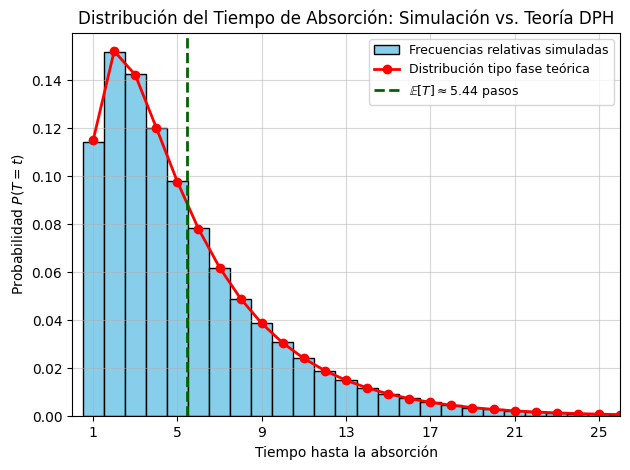

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_individuos = 1000000

estados = [0,1,2]

P = np.array([
    [1,0,0],
    [0.1,0.5,0.4],
    [0.25,0.1,0.65]
])

# Vector de distribucion inicial para los estados transitorios
alpha = np.array([0.9, 0.1])

# Simulacion estocastica de los tiempos de absorcion para N individuos
t_abs_sim = t_abs_multinomial(N_individuos,P,estados,alpha,max_pasos=10000)
max_tiempo = max(t_abs_sim) if len(t_abs_sim) > 0 else 0
ejex_tiempos = np.arange(1, max_tiempo + 1)

# Calculo teorico de la distribucion de los tiempos de absorcion, de acuerdo
# a la teoria de distribuciondes tipo fase

# Dividimos en submatrices la matriz P de transicion
Q = P[1:, 1:]
q = P[1:, 0]

probabilidades_teoricas = []

# Calculamos \alpha * S^{t-1} * s para cada paso de tiempo
for t in ejex_tiempos:
    Q_potencia = np.linalg.matrix_power(Q, t - 1)
    p_t = np.dot(np.dot(alpha, Q_potencia), q)
    probabilidades_teoricas.append(p_t)

# Histograma de frecuencias simuladas
pesos = np.ones_like(t_abs_sim) / len(t_abs_sim)
plt.hist(t_abs_sim, bins=np.arange(0.5, max_tiempo + 1.5, 1),
         weights=pesos, color='skyblue',
         edgecolor='black', label='Frecuencias relativas simuladas')

# Curva teórica phase type
plt.plot(ejex_tiempos, probabilidades_teoricas, 'r-o', linewidth=2,
         label=r'Distribución tipo fase teórica')

#Tiempos de absorción simulados del histograma
tiempo_promedio_sim = np.mean(t_abs_sim)
print(f"Tiempo promedio simulado: {tiempo_promedio_sim:.4f}")

# Cota 1/N
umbral = 1.0 / N_individuos
unos = np.ones(Q.shape[0])

# Encontrar t_N usando la ecuación 5 del cartel
t_N_teorico = 0
for t in range(1, max_tiempo + 1):
    Q_potencia = np.linalg.matrix_power(Q, t)
    # m_barra(t) = alpha * Q^t * 1
    m_barra = np.dot(np.dot(alpha, Q_potencia), unos)

    if m_barra <= umbral:
        t_N_teorico = t
        break

print(f"Tiempo de absorcion teorico t_N: {t_N_teorico} pasos")

I = np.eye(Q.shape[0])
E_T = np.dot(np.dot(alpha, np.linalg.inv(I - Q)), unos)
print(f"Esperanza matemática individual E[T]: {E_T:.4f} pasos")

# Línea vertical para el valor esperado individual
plt.axvline(x=tiempo_promedio_sim, color='darkgreen', linestyle='--', linewidth=2,
            label=f'$\\mathbb{{E}}[T] \\approx {tiempo_promedio_sim:.2f}$ pasos')


plt.title('Distribución del Tiempo de Absorción: Simulación vs. Teoría DPH', fontsize=12)
plt.xlabel('Tiempo hasta la absorción', fontsize=10)
plt.ylabel('Probabilidad $P(T=t)$', fontsize=10)
plt.xticks(np.arange(1, max_tiempo + 1, max(1, max_tiempo // 15)))
plt.grid(True, alpha=0.5)
plt.legend(fontsize=9, loc='upper right')
plt.xlim(0, 26)
plt.tight_layout()
plt.show()

In [22]:
#Tiempos de absorción simulados del histograma
tiempo_promedio_sim = np.mean(t_abs_sim)
print(f"Tiempo promedio simulado: {tiempo_promedio_sim:.4f}")

# Cota 1/N
umbral = 1.0 / N_individuos
unos = np.ones(Q.shape[0])

# Encontrar t_N usando la ecuación 5 del cartel
t_N_teorico = 0
for t in range(1, max_tiempo + 1):
    Q_potencia = np.linalg.matrix_power(Q, t)
    # m_barra(t) = alpha * Q^t * 1
    m_barra = np.dot(np.dot(alpha, Q_potencia), unos)

    if m_barra <= umbral:
        t_N_teorico = t
        break

print(f"Tiempo de absorcion teorico t_N: {t_N_teorico} pasos")

I = np.eye(Q.shape[0])
E_T = np.dot(np.dot(alpha, np.linalg.inv(I - Q)), unos)
print(f"Esperanza matemática individual E[T]: {E_T:.4f} pasos")

Tiempo promedio simulado: 5.4479
Tiempo de absorcion teorico t_N: 60 pasos
Esperanza matemática individual E[T]: 5.4444 pasos
